# Supervised Learning: Analisis Regresi Z-Score (HAZ & WAZ) untuk Deteksi Stunting Balita

In [1]:
# Mengimpor pustaka utama untuk pemodelan regresi, cross-validation, optimasi Optuna, dan analisis residual
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import optuna
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Mengatur resolusi grafik matplotlib secara global ke 300 DPI untuk standar publikasi
mpl.rcParams['figure.dpi'] = 300
sns.set_theme(style='whitegrid')
print("Seluruh pustaka regresi berhasil diimpor dengan konfigurasi visualisasi 300 DPI!")

/home/haerulyudaaditiya/Downloads/exp/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Seluruh pustaka regresi berhasil diimpor dengan konfigurasi visualisasi 300 DPI!


## 1. Memuat Dataset Balita dan Tabel Referensi WHO
Memuat dataset anak dan melakukan pra-pemrosesan standar.

In [2]:
# Memuat dataset utama
df_ml = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/stunting_wasting_dataset.csv')

# Memuat tabel referensi standar WHO Z-scores
who_lhfa_boys = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/z-scores who/lhfa_boys_0-to-5-years_zscores.csv', sep=';', decimal=',')
who_lhfa_girls = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/z-scores who/lhfa_girls_0-to-5-years_zscores.csv', sep=';', decimal=',')
who_wfa_boys = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/z-scores who/wfa_boys_0-to-5-years_zscores.csv', sep=';', decimal=',')
who_wfa_girls = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/z-scores who/wfa_girls_0-to-5-years_zscores.csv', sep=';', decimal=',')

# Menstandarkan nama kolom pertama menjadi 'c'
who_lhfa_boys = who_lhfa_boys.rename(columns={who_lhfa_boys.columns[0]: 'c'})
who_lhfa_girls = who_lhfa_girls.rename(columns={who_lhfa_girls.columns[0]: 'c'})
who_wfa_boys = who_wfa_boys.rename(columns={who_wfa_boys.columns[0]: 'c'})
who_wfa_girls = who_wfa_girls.rename(columns={who_wfa_girls.columns[0]: 'c'})

print("Data regresi berhasil dimuat!")

Data regresi berhasil dimuat!


## 2. Feature Engineering: Perhitungan Z-score Kontinu
Menghitung nilai continuous HAZ dan WAZ sebagai target regresi.

In [3]:
def compute_z_scores(df_main, df_who_lhfa, df_who_wfa):
    original_index = df_main.index

    # 1. HAZ
    df_merged = pd.merge(df_main, df_who_lhfa[['c', 'L', 'M', 'S']], left_on='Umur (bulan)', right_on='c', how='left')
    X_h = df_merged['Tinggi Badan (cm)']
    L_h = df_merged['L']
    M_h = df_merged['M']
    S_h = df_merged['S']
    df_merged['HAZ'] = (((X_h / M_h) ** L_h) - 1) / (L_h * S_h)
    df_merged = df_merged.drop(columns=['c', 'L', 'M', 'S'])

    # 2. WAZ
    df_merged = pd.merge(df_merged, df_who_wfa[['c', 'L', 'M', 'S']], left_on='Umur (bulan)', right_on='c', how='left')
    X_w = df_merged['Berat Badan (kg)']
    L_w = df_merged['L']
    M_w = df_merged['M']
    S_w = df_merged['S']
    df_merged['WAZ'] = np.where(L_w == 0,
                                np.log(X_w / M_w) / S_w,
                                (((X_w / M_w) ** L_w) - 1) / (L_w * S_w))
    df_merged = df_merged.drop(columns=['c', 'L', 'M', 'S'])

    df_merged.index = original_index
    return df_merged

df_boys = df_ml[df_ml['Jenis Kelamin'] == 'Laki-laki'].copy()
df_girls = df_ml[df_ml['Jenis Kelamin'] == 'Perempuan'].copy()

df_boys_enriched = compute_z_scores(df_boys, who_lhfa_boys, who_wfa_boys)
df_girls_enriched = compute_z_scores(df_girls, who_lhfa_girls, who_wfa_girls)

df_final = pd.concat([df_boys_enriched, df_girls_enriched]).sort_index()
df_final.head()

,Jenis Kelamin,Umur (bulan),Tinggi Badan (cm),Berat Badan (kg),Stunting,Wasting,HAZ,WAZ
0,Laki-laki,19,91.6,13.3,Tall,Risk of Overweight,3.033495,1.587105
1,Laki-laki,20,77.7,8.5,Stunted,Underweight,-2.309778,-2.572957
2,Laki-laki,10,79.0,10.3,Normal,Risk of Overweight,2.502858,1.077254
3,Perempuan,2,50.3,8.3,Severely Stunted,Risk of Overweight,-3.323558,3.790974
4,Perempuan,5,56.4,10.9,Severely Stunted,Risk of Overweight,-3.441070,3.690638


## 3. Analisis Eksplorasi Data (EDA) - 300 DPI
Menampilkan density joint plot untuk tinggi badan vs usia anak.

<Figure size 3000x2400 with 0 Axes>

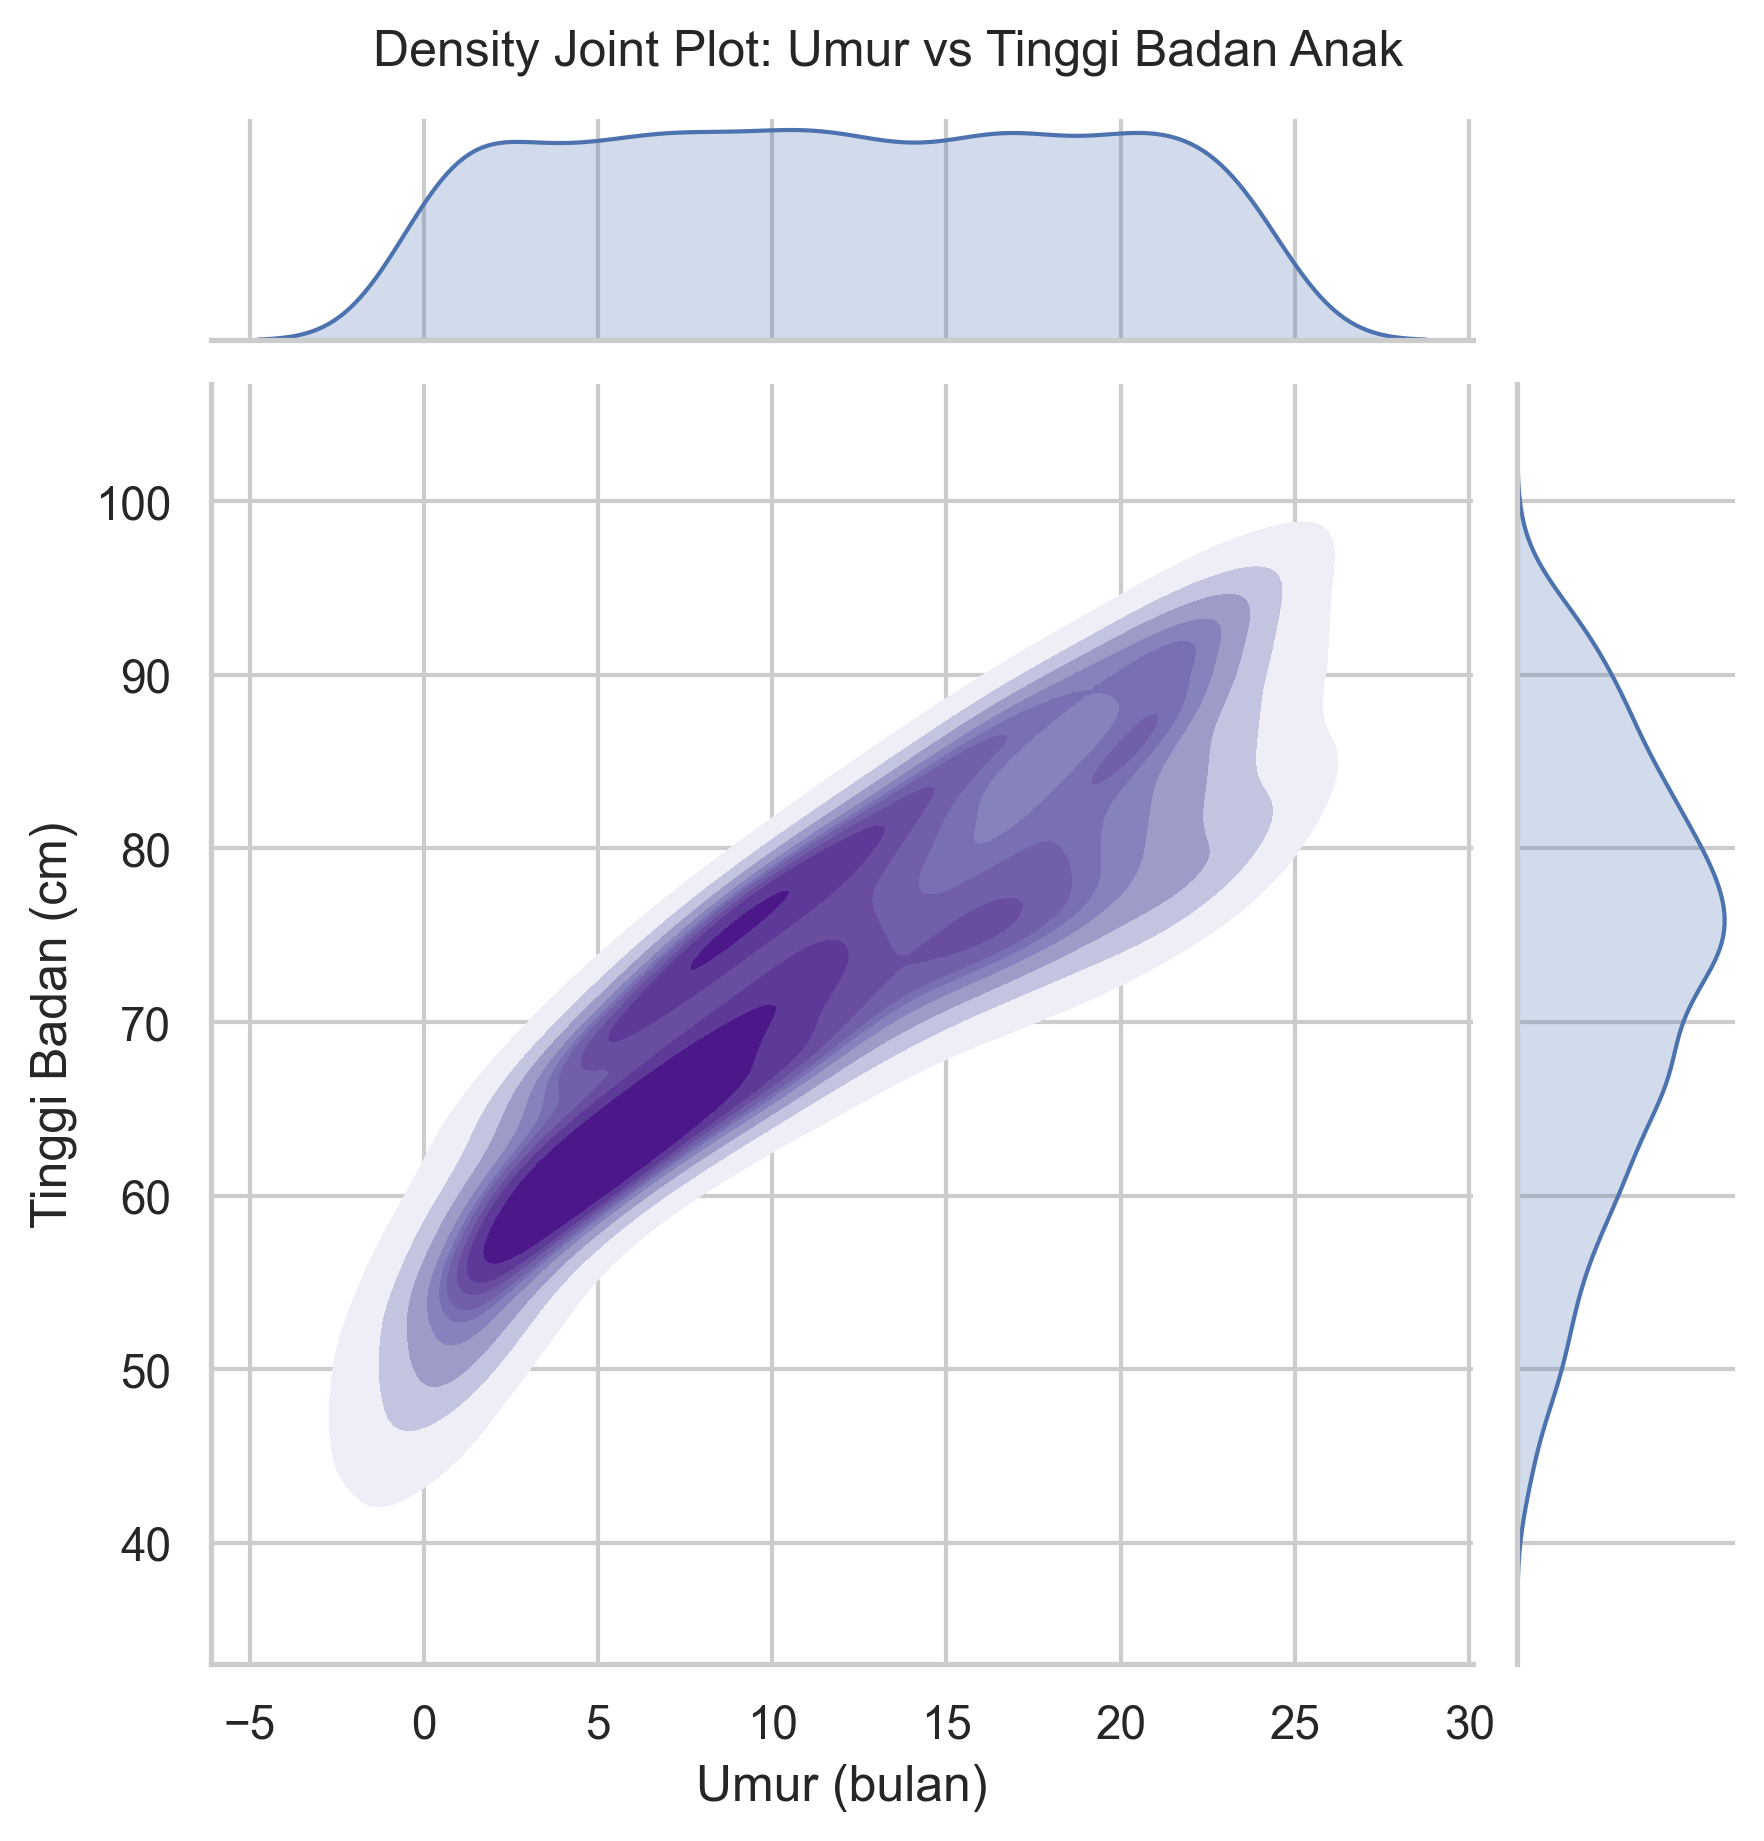

In [4]:
plt.figure(figsize=(10, 8))
g = sns.jointplot(
    data=df_final.sample(2000, random_state=42),
    x='Umur (bulan)',
    y='Tinggi Badan (cm)',
    kind='kde',
    cmap='Purples',
    fill=True
)
g.fig.suptitle('Density Joint Plot: Umur vs Tinggi Badan Anak', y=1.02, fontsize=12)
plt.savefig('results/regression/jointplot_regresi_stunting.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Pemisahan Fitur (Feature Decoupling) & Persiapan Input
Untuk mencegah *feature noise*, kita memisahkan input data:
- **Fitur HAZ**: `Jenis Kelamin`, `Umur`, dan `Tinggi Badan` (tanpa Berat Badan).
- **Fitur WAZ**: `Jenis Kelamin`, `Umur`, dan `Berat Badan` (tanpa Tinggi Badan).

In [5]:
gender_encoder = LabelEncoder()
df_final['Jenis Kelamin_Encoded'] = gender_encoder.fit_transform(df_final['Jenis Kelamin'])

# Decoupled Input untuk HAZ
X_haz = df_final[['Jenis Kelamin_Encoded', 'Umur (bulan)', 'Tinggi Badan (cm)']]
y_haz = df_final['HAZ']

# Decoupled Input untuk WAZ
X_waz = df_final[['Jenis Kelamin_Encoded', 'Umur (bulan)', 'Berat Badan (kg)']]
y_waz = df_final['WAZ']

print(f"Fitur HAZ didekopling: {X_haz.columns.tolist()}")
print(f"Fitur WAZ didekopling: {X_waz.columns.tolist()}")

Fitur HAZ didekopling: ['Jenis Kelamin_Encoded', 'Umur (bulan)', 'Tinggi Badan (cm)']
Fitur WAZ didekopling: ['Jenis Kelamin_Encoded', 'Umur (bulan)', 'Berat Badan (kg)']


## 5. Pemodelan Baseline & Evaluasi 5-Fold Cross Validation
Mengevaluasi 6 model regresi untuk memprediksi `HAZ` menggunakan K-Fold Cross-Validation lipat 5.

In [6]:
models_reg = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1),
    'CatBoost': CatBoostRegressor(random_seed=42, verbose=0)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
results_haz = {}

print("Mengevaluasi Model Regresi HAZ (5-Fold CV):")
for name, model in models_reg.items():
    mae_scores = []
    rmse_scores = []
    r2_scores = []

    for train_idx, val_idx in cv.split(X_haz, y_haz):
        X_tr, X_val = X_haz.iloc[train_idx], X_haz.iloc[val_idx]
        y_tr, y_val = y_haz.iloc[train_idx], y_haz.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)

        mae_scores.append(mean_absolute_error(y_val, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
        r2_scores.append(r2_score(y_val, preds))

    results_haz[name] = {
        'MAE': f"{np.mean(mae_scores):.6f} +/- {np.std(mae_scores):.6f}",
        'RMSE': f"{np.mean(rmse_scores):.6f} +/- {np.std(rmse_scores):.6f}",
        'R2': f"{np.mean(r2_scores):.6f} +/- {np.std(r2_scores):.6f}"
    }
    print(f"- {name} R2-Score: {np.mean(r2_scores):.6f}")

pd.DataFrame(results_haz).T

Mengevaluasi Model Regresi HAZ (5-Fold CV):
- Linear Regression R2-Score: 0.821388
- Ridge Regression R2-Score: 0.821388
- Random Forest R2-Score: 1.000000
- XGBoost R2-Score: 0.999159
- LightGBM R2-Score: 0.997572
- CatBoost R2-Score: 0.999577


,MAE,RMSE,R2
Linear Regression,0.616804 +/- 0.002632,0.832813 +/- 0.006291,0.821388 +/- 0.003024
Ridge Regression,0.616804 +/- 0.002632,0.832813 +/- 0.006291,0.821388 +/- 0.003024
Random Forest,0.000107 +/- 0.000001,0.000795 +/- 0.000093,1.000000 +/- 0.000000
XGBoost,0.042235 +/- 0.000483,0.057139 +/- 0.000827,0.999159 +/- 0.000021
LightGBM,0.075526 +/- 0.001120,0.097089 +/- 0.001474,0.997572 +/- 0.000069
CatBoost,0.026380 +/- 0.000215,0.040547 +/- 0.000363,0.999577 +/- 0.000007


## 6. Optimasi Hiperparameter Menggunakan Optuna
Melakukan tuning parameter LGBMRegressor untuk meminimalkan MAE nilai HAZ.

In [7]:
X_train_h, X_val_h, y_train_h, y_val_h = train_test_split(X_haz, y_haz, test_size=0.2, random_state=42)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'verbose': -1,
        'random_state': 42,
        'n_jobs': -1
    }
    model = LGBMRegressor(**params)
    model.fit(X_train_h, y_train_h)
    preds = model.predict(X_val_h)
    return mean_absolute_error(y_val_h, preds)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("Parameter terbaik hasil Optuna:")
print(study.best_params)

Parameter terbaik hasil Optuna:
{'n_estimators': 99, 'max_depth': 8, 'learning_rate': 0.12163749733034963, 'num_leaves': 43}


## 7. Pelatihan Model Teroptimasi Final & Analisis Residu
Melatih model final LightGBM teroptimasi untuk HAZ dan WAZ.

In [8]:
# Melatih model HAZ terbaik pada seluruh data
best_lgbm_haz = LGBMRegressor(**study.best_params, verbose=-1, random_state=42, n_jobs=-1)
best_lgbm_haz.fit(X_haz, y_haz)

# Melatih model WAZ terbaik pada seluruh data (menggunakan parameter optimal yang serupa)
best_lgbm_waz = LGBMRegressor(**study.best_params, verbose=-1, random_state=42, n_jobs=-1)
best_lgbm_waz.fit(X_waz, y_waz)

print("Kedua model final teroptimasi HAZ & WAZ berhasil dilatih!")

Kedua model final teroptimasi HAZ & WAZ berhasil dilatih!


### 7.1 Plot Residu Diagnostik (300 DPI)
Menampilkan sebaran error prediksi vs nilai aktual serta normalitas distribusi residu.

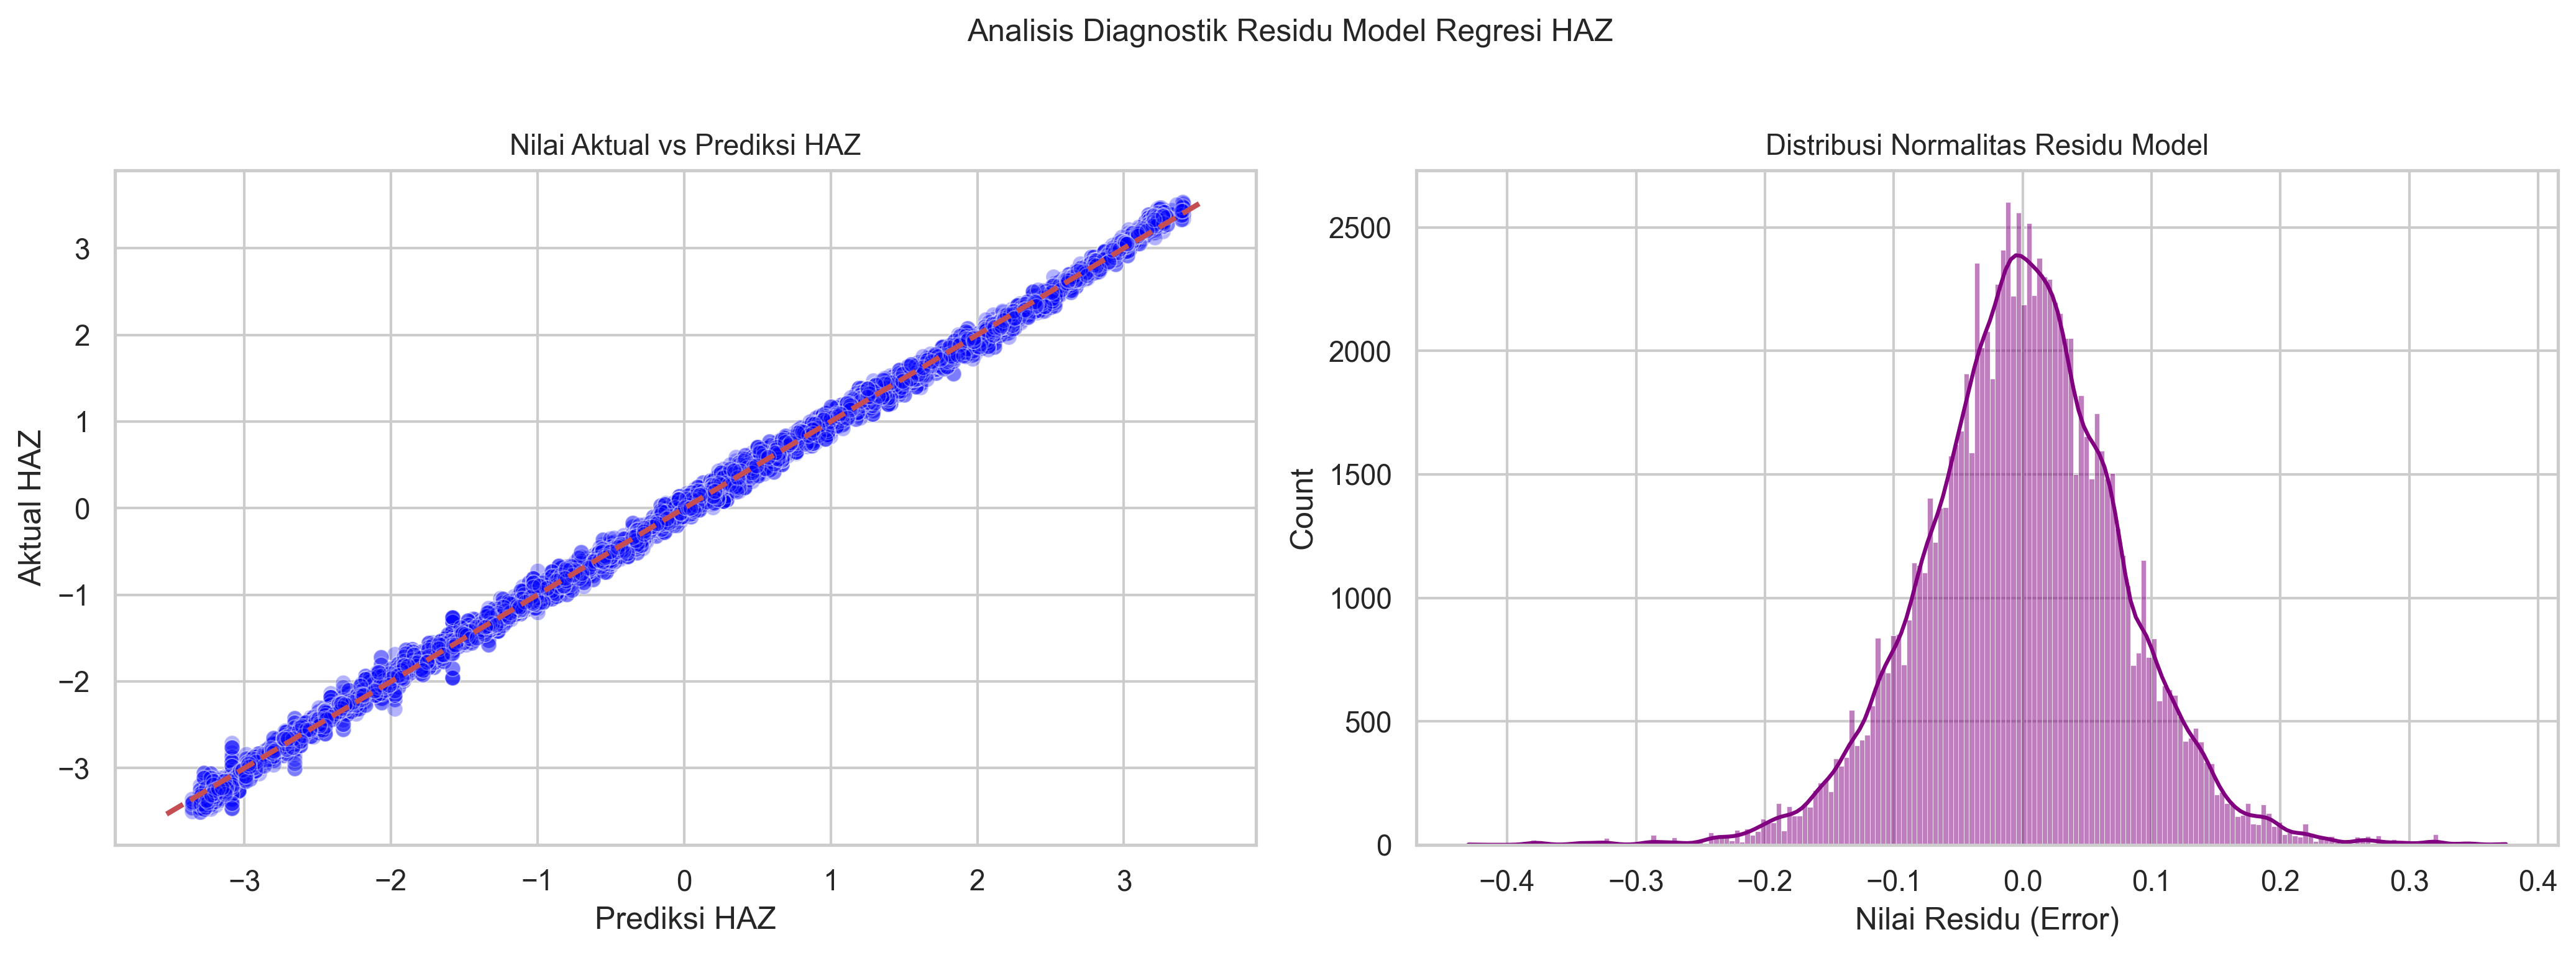

In [9]:
haz_preds = best_lgbm_haz.predict(X_haz)
residuals = y_haz - haz_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Prediksi vs Aktual
sns.scatterplot(x=haz_preds[::10], y=y_haz[::10], alpha=0.3, ax=axes[0], color='blue')
axes[0].plot([y_haz.min(), y_haz.max()], [y_haz.min(), y_haz.max()], 'r--', lw=2)
axes[0].set_title('Nilai Aktual vs Prediksi HAZ', fontsize=11)
axes[0].set_xlabel('Prediksi HAZ')
axes[0].set_ylabel('Aktual HAZ')

# Distribusi Residu
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Distribusi Normalitas Residu Model', fontsize=11)
axes[1].set_xlabel('Nilai Residu (Error)')

plt.suptitle('Analisis Diagnostik Residu Model Regresi HAZ', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('results/regression/analisis_residu_regresi.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Analisis Kontribusi Fitur Menggunakan SHAP
Menjelaskan kepentingan fitur fisik secara lokal/global terhadap hasil prediksi skor HAZ.

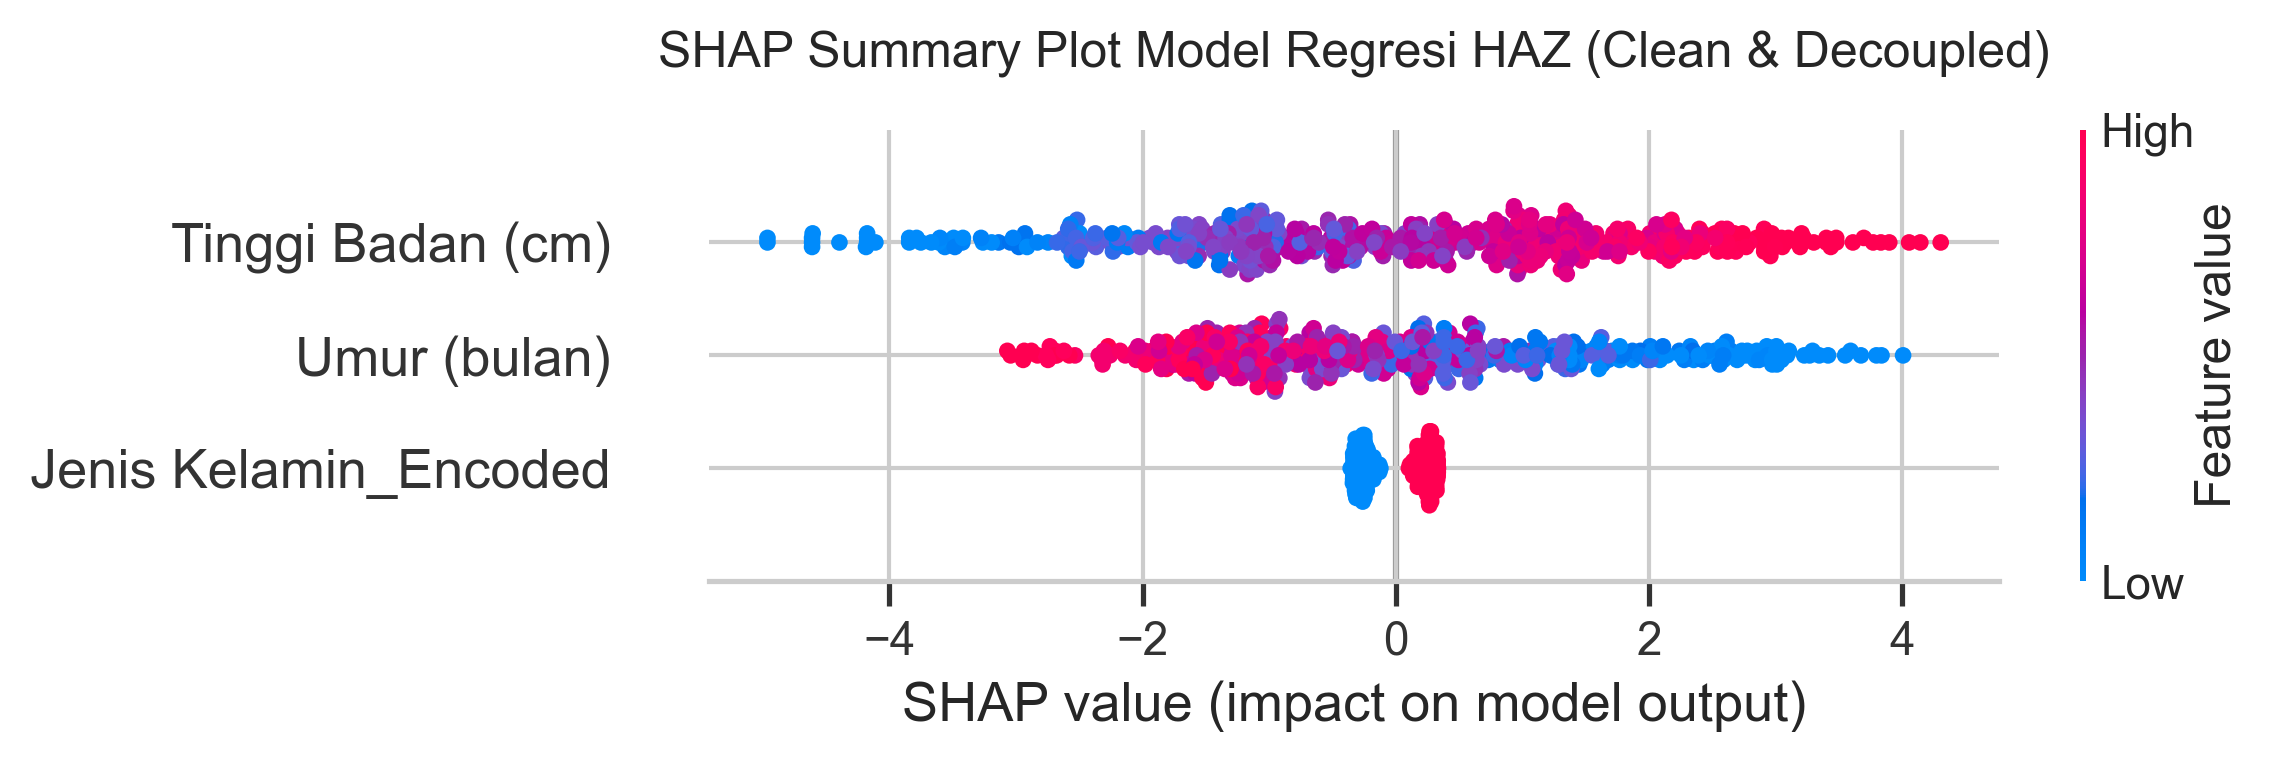

In [10]:
explainer = shap.TreeExplainer(best_lgbm_haz)
X_sample = X_haz.sample(500, random_state=42)
shap_values = explainer(X_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Summary Plot Model Regresi HAZ (Clean & Decoupled)', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('results/regression/shap_summary_regression.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Model Serialization & Pipa Inferensi Regresi Z-score (MLOps)
Menyimpan model regresi HAZ dan WAZ terlatih serta menyediakan fungsi prediksi terintegrasi dengan validasi input data.

In [11]:
# Menyimpan model regresi
joblib.dump(best_lgbm_haz, 'results/regression/stunting_lgbm_reg_haz.joblib')
joblib.dump(best_lgbm_waz, 'results/regression/stunting_lgbm_reg_waz.joblib')
print("Model regresi HAZ & WAZ sukses disimpan di folder results/regression/!")

# Pipa Inferensi Mandiri dengan Proteksi GIGO
def estimasi_z_score(jenis_kelamin, umur_bulan, tinggi_cm, berat_kg):
    # 1. Proteksi batas biologis input
    if not (0 <= umur_bulan <= 60):
        raise ValueError("Umur balita harus dalam rentang biologis 0 - 60 bulan.")
    if not (30 <= tinggi_cm <= 120):
        raise ValueError("Tinggi badan harus dalam rentang biologis 30 - 120 cm.")
    if not (2 <= berat_kg <= 30):
        raise ValueError("Berat badan harus dalam rentang biologis 2 - 30 kg.")
    if jenis_kelamin not in ['Laki-laki', 'Perempuan']:
        raise ValueError("Jenis kelamin harus 'Laki-laki' atau 'Perempuan'.")

    # 2. Transformasi input
    gender_enc = gender_encoder.transform([jenis_kelamin])[0]

    # 3. Prediksi HAZ (Decoupled)
    input_haz = pd.DataFrame([{
        'Jenis Kelamin_Encoded': gender_enc,
        'Umur (bulan)': umur_bulan,
        'Tinggi Badan (cm)': tinggi_cm
    }])
    pred_haz = best_lgbm_haz.predict(input_haz)[0]

    # 4. Prediksi WAZ (Decoupled)
    input_waz = pd.DataFrame([{
        'Jenis Kelamin_Encoded': gender_enc,
        'Umur (bulan)': umur_bulan,
        'Berat Badan (kg)': berat_kg
    }])
    pred_waz = best_lgbm_waz.predict(input_waz)[0]

    return pred_haz, pred_waz

# Contoh pengujian inferensi regresi baru
haz_val, waz_val = estimasi_z_score(jenis_kelamin='Perempuan', umur_bulan=24, tinggi_cm=82.0, berat_kg=10.5)
print(f"Estimasi Skor Balita - HAZ: {haz_val:.4f}, WAZ: {waz_val:.4f}")

Model regresi HAZ & WAZ sukses disimpan di folder results/regression/!
Estimasi Skor Balita - HAZ: -1.2109, WAZ: -0.7191
